In [1]:
# ============================================================
# INSTALL ADDITIONAL PACKAGE
# ============================================================

!pip -q install lifetimes

In [2]:
# ============================================================
# LIBRARIES
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================

local_path = r"Paste Data File Path Here"

if os.path.exists(local_path):

    data_path = local_path
    print("Local dataset found.")

else:

    print("Local file was not found.")
    print("If you are using Google Colab, upload the CSV file below.")

    try:
        from google.colab import files

        uploaded = files.upload()

        data_path = next(iter(uploaded))

    except Exception:

        raise FileNotFoundError(
            "Dataset not found. Please check the file path."
        )

df = pd.read_csv(
    data_path,
    encoding="ISO-8859-1"
)

print("Dataset loaded successfully.")
print("Path:", data_path)
print("Shape:", df.shape)

Local dataset found.
Dataset loaded successfully.
Path: C:\Users\rkdas\OneDrive\Documents\Desktop\Project\CRM\Year 2009-2010.csv\Year 2009-2010.csv
Shape: (525461, 8)


In [4]:
# ============================================================
# INITIAL DATA INSPECTION
# ============================================================

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five records:")
display(df.head())

print("\nData types:")
display(df.dtypes)

Dataset shape: (525461, 8)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First five records:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,"13,085.00",United Kingdom



Data types:


Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

In [5]:
# ============================================================
# STANDARDIZE COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country']


In [7]:
# ============================================================
# REQUIRED COLUMN CHECK
# ============================================================

required_columns = {
    "invoice",
    "stockcode",
    "quantity",
    "invoicedate",
    "price",
    "customer_id"
}

missing_columns = required_columns - set(df.columns)

if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required columns are available.")

All required columns are available.


In [8]:
# ============================================================
# DATA QUALITY REPORT
# ============================================================

quality_report = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Missing_Values": df.isna().sum(),
    "Missing_%": (
        df.isna().mean() * 100
    ),
    "Unique_Values": df.nunique()
})

display(
    quality_report.sort_values(
        "Missing_Values",
        ascending=False
    )
)

,Data_Type,Missing_Values,Missing_%,Unique_Values
customer_id,float64,107927,20.54,4383
description,object,2928,0.56,4681
stockcode,object,0,0.00,4632
invoice,object,0,0.00,28816
quantity,int64,0,0.00,825
invoicedate,object,0,0.00,25296
price,float64,0,0.00,1606
country,object,0,0.00,40


In [9]:
# ============================================================
# DUPLICATE CHECK
# ============================================================

duplicate_count = df.duplicated().sum()

print(
    f"Duplicate rows found: {duplicate_count:,}"
)

if duplicate_count > 0:

    df = (
        df
        .drop_duplicates()
        .reset_index(drop=True)
    )

print(
    "Shape after duplicate handling:",
    df.shape
)

Duplicate rows found: 6,865
Shape after duplicate handling: (518596, 8)


In [11]:
# ============================================================
# TYPE CONVERSION
# ============================================================

df["invoicedate"] = pd.to_datetime(
    df["invoicedate"],
    errors="coerce"
)

df["quantity"] = pd.to_numeric(
    df["quantity"],
    errors="coerce"
)

df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)

df["customer_id"] = pd.to_numeric(
    df["customer_id"],
    errors="coerce"
)

print(df.dtypes)

invoice                object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
price                 float64
customer_id           float64
country                object
dtype: object


In [12]:
# ============================================================
# MISSING CUSTOMER IDENTIFIERS
# ============================================================

missing_customer_ids = df["customer_id"].isna().sum()

print(
    f"Rows without Customer ID: {missing_customer_ids:,}"
)

df = df.dropna(
    subset=["customer_id"]
).copy()

df["customer_id"] = (
    df["customer_id"]
    .astype(int)
    .astype(str)
)

print(
    "Remaining rows:",
    len(df)
)

Rows without Customer ID: 107,833
Remaining rows: 410763


In [13]:
# ============================================================
# CANCELLATION ANALYSIS
# ============================================================

df["invoice_str"] = (
    df["invoice"]
    .astype(str)
    .str.strip()
)

df["is_cancelled"] = (
    df["invoice_str"]
    .str.upper()
    .str.startswith("C")
)

cancellation_summary = pd.DataFrame({
    "Transaction_Type": [
        "Regular",
        "Cancelled"
    ],
    "Rows": [
        (~df["is_cancelled"]).sum(),
        df["is_cancelled"].sum()
    ]
})

cancellation_summary["Percentage"] = (
    cancellation_summary["Rows"]
    / len(df)
    * 100
)

display(cancellation_summary)

,Transaction_Type,Rows,Percentage
0,Regular,400947,97.61
1,Cancelled,9816,2.39


In [15]:
# ============================================================
# REVENUE ENGINEERING
# ============================================================

df["revenue"] = (
    df["quantity"]
    * df["price"]
)

display(
    df[
        [
            "invoice",
            "stockcode",
            "quantity",
            "price",
            "revenue"
        ]
    ].head()
)

,invoice,stockcode,quantity,price,revenue
0,489434,85048,12,6.95,83.40
1,489434,79323P,12,6.75,81.00
2,489434,79323W,12,6.75,81.00
3,489434,22041,48,2.10,100.80
4,489434,21232,24,1.25,30.00


In [17]:
# ============================================================
# ANALYTICAL TRANSACTION DATASET
# ============================================================

transactions = df[
    (~df["is_cancelled"])
    &
    (df["quantity"] > 0)
    &
    (df["price"] > 0)
    &
    (df["revenue"] > 0)
    &
    (df["invoicedate"].notna())
].copy()

transactions = transactions.sort_values(
    "invoicedate"
).reset_index(drop=True)

print(
    "Raw rows:",
    len(df)
)

print(
    "Analytical transaction rows:",
    len(transactions)
)

print(
    "Unique customers:",
    transactions["customer_id"].nunique()
)

print(
    "Unique invoices:",
    transactions["invoice_str"].nunique()
)

Raw rows: 410763
Analytical transaction rows: 400916
Unique customers: 4312
Unique invoices: 19213


In [18]:
# ============================================================
# FINAL DATA QUALITY CHECK
# ============================================================

print("Missing values:")
display(
    transactions.isna().sum()
    .sort_values(ascending=False)
    .head(15)
)

print("\nNegative quantities:")
print(
    (transactions["quantity"] < 0).sum()
)

print("\nNegative revenue:")
print(
    (transactions["revenue"] < 0).sum()
)

print("\nDate range:")
print(
    transactions["invoicedate"].min(),
    "to",
    transactions["invoicedate"].max()
)

Missing values:


invoice         0
stockcode       0
description     0
quantity        0
invoicedate     0
price           0
customer_id     0
country         0
invoice_str     0
is_cancelled    0
revenue         0
dtype: int64


Negative quantities:
0

Negative revenue:
0

Date range:
2009-12-01 07:45:00 to 2010-12-09 20:01:00


In [19]:
# ============================================================
# BUSINESS KPI SUMMARY
# ============================================================

total_revenue = transactions["revenue"].sum()

total_orders = (
    transactions["invoice_str"]
    .nunique()
)

total_customers = (
    transactions["customer_id"]
    .nunique()
)

total_products = (
    transactions["stockcode"]
    .nunique()
)

total_units = (
    transactions["quantity"]
    .sum()
)

average_order_value = (
    total_revenue
    / total_orders
)

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Unique Customers",
        "Unique Products",
        "Units Sold",
        "Average Order Value"
    ],

    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        total_products,
        total_units,
        average_order_value
    ]
})

display(kpi_summary)

,KPI,Value
0,Total Revenue,"8,798,233.74"
1,Total Orders,"19,213.00"
2,Unique Customers,"4,312.00"
3,Unique Products,"4,017.00"
4,Units Sold,"5,519,578.00"
5,Average Order Value,457.93


In [20]:
# ============================================================
# MONTHLY REVENUE TREND
# ============================================================

transactions["invoice_month"] = (
    transactions["invoicedate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_sales = (
    transactions
    .groupby("invoice_month")
    .agg(
        revenue=("revenue", "sum"),
        orders=("invoice_str", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

monthly_sales["aov"] = (
    monthly_sales["revenue"]
    / monthly_sales["orders"]
)

display(monthly_sales)

,invoice_month,revenue,orders,customers,aov
0,2009-12-01,"683,504.01",1512,955,452.05
1,2010-01-01,"555,802.67",1011,720,549.76
2,2010-02-01,"504,558.96",1104,772,457.03
3,2010-03-01,"696,978.47",1524,1057,457.33
4,2010-04-01,"591,982.00",1329,942,445.43
5,2010-05-01,"597,833.38",1377,966,434.16
6,2010-06-01,"636,371.13",1497,1041,425.10
7,2010-07-01,"589,736.17",1381,928,427.04
8,2010-08-01,"602,224.60",1293,911,465.76
9,2010-09-01,"829,013.95",1689,1145,490.83


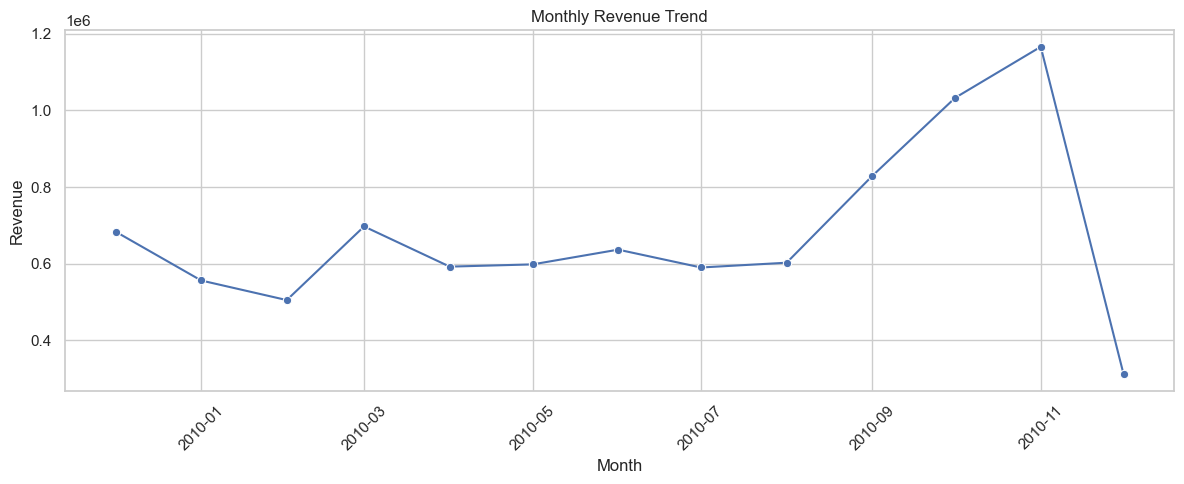

In [21]:
# ============================================================
# MONTHLY REVENUE VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="invoice_month",
    y="revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# TOP PRODUCTS BY REVENUE
# ============================================================

product_summary = (
    transactions
    .groupby(
        ["stockcode", "description"],
        dropna=False
    )
    .agg(
        revenue=("revenue", "sum"),
        units=("quantity", "sum"),
        orders=("invoice_str", "nunique")
    )
    .reset_index()
)

top_products = (
    product_summary
    .sort_values(
        "revenue",
        ascending=False
    )
    .head(15)
)

display(top_products)

,stockcode,description,revenue,units,orders
3930,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"151,339.16",56814,3021
1828,22423,REGENCY CAKESTAND 3 TIER,"143,727.60",12484,1687
4466,M,Manual,"98,531.99",2568,382
3642,84879,ASSORTED COLOUR BIRD ORNAMENT,"70,291.03",44431,1333
3905,85099B,JUMBO BAG RED RETROSPOT,"51,644.25",29519,1060
4468,POST,POSTAGE,"48,741.08",2212,738
3276,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"40,156.05",21579,244
1430,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"36,871.55",13839,796
2837,47566,PARTY BUNTING,"35,017.30",8312,710
23,15056N,EDWARDIAN PARASOL NATURAL,"34,044.75",7201,496


In [23]:
# ============================================================
# COUNTRY-LEVEL PERFORMANCE
# ============================================================

country_summary = (
    transactions
    .groupby("country")
    .agg(
        revenue=("revenue", "sum"),
        customers=("customer_id", "nunique"),
        orders=("invoice_str", "nunique")
    )
    .reset_index()
)

country_summary["revenue_per_customer"] = (
    country_summary["revenue"]
    / country_summary["customers"]
)

display(
    country_summary
    .sort_values(
        "revenue",
        ascending=False
    )
    .head(15)
)

,country,revenue,customers,orders,revenue_per_customer
34,United Kingdom,"7,381,644.43",3969,17612,"1,859.82"
9,EIRE,"356,041.86",5,316,"71,208.37"
21,Netherlands,"268,784.35",22,135,"12,217.47"
12,Germany,"202,025.39",67,347,"3,015.30"
11,France,"146,107.07",47,236,"3,108.66"
29,Sweden,"53,147.99",16,68,"3,321.75"
8,Denmark,"50,906.85",9,26,"5,656.32"
28,Spain,"47,568.65",25,66,"1,902.75"
30,Switzerland,"43,921.39",14,40,"3,137.24"
0,Australia,"31,446.80",15,40,"2,096.45"


In [24]:
# ============================================================
# CUSTOMER-LEVEL TRANSACTION SUMMARY
# ============================================================

customer_summary = (
    transactions
    .groupby("customer_id")
    .agg(
        first_purchase=("invoicedate", "min"),
        last_purchase=("invoicedate", "max"),
        orders=("invoice_str", "nunique"),
        items=("quantity", "sum"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

customer_summary["customer_lifetime_days"] = (
    customer_summary["last_purchase"]
    - customer_summary["first_purchase"]
).dt.days

customer_summary["average_order_value"] = (
    customer_summary["revenue"]
    / customer_summary["orders"]
)

display(
    customer_summary.head()
)

,customer_id,first_purchase,last_purchase,orders,items,revenue,customer_lifetime_days,average_order_value
0,12346,2009-12-14 08:34:00,2010-06-28 13:53:00,11,70,372.86,196,33.90
1,12347,2010-10-31 14:20:00,2010-12-07 14:57:00,2,828,"1,323.32",37,661.66
2,12348,2010-09-27 14:59:00,2010-09-27 14:59:00,1,373,222.16,0,222.16
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,3,993,"2,671.14",181,890.38
4,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,261,300.93,0,300.93


In [25]:
# ============================================================
# RFM REFERENCE DATE
# ============================================================

analysis_date = (
    transactions["invoicedate"].max()
    + pd.Timedelta(days=1)
)

print(
    "Latest transaction:",
    transactions["invoicedate"].max()
)

print(
    "RFM analysis date:",
    analysis_date
)

Latest transaction: 2010-12-09 20:01:00
RFM analysis date: 2010-12-10 20:01:00


In [26]:
# ============================================================
# RFM METRICS
# ============================================================

rfm = (
    transactions
    .groupby("customer_id")
    .agg(
        Recency=(
            "invoicedate",
            lambda x: (
                analysis_date - x.max()
            ).days
        ),

        Frequency=(
            "invoice_str",
            "nunique"
        ),

        Monetary=(
            "revenue",
            "sum"
        )
    )
    .reset_index()
)

display(
    rfm.describe().T
)

,count,mean,std,min,25%,50%,75%,max
Recency,"4,312.00",91.17,96.86,1.00,18.00,53.00,136.00,374.00
Frequency,"4,312.00",4.46,8.17,1.00,1.00,2.00,5.00,205.00
Monetary,"4,312.00","2,040.41","8,911.76",2.95,307.19,701.62,"1,714.93","349,164.35"


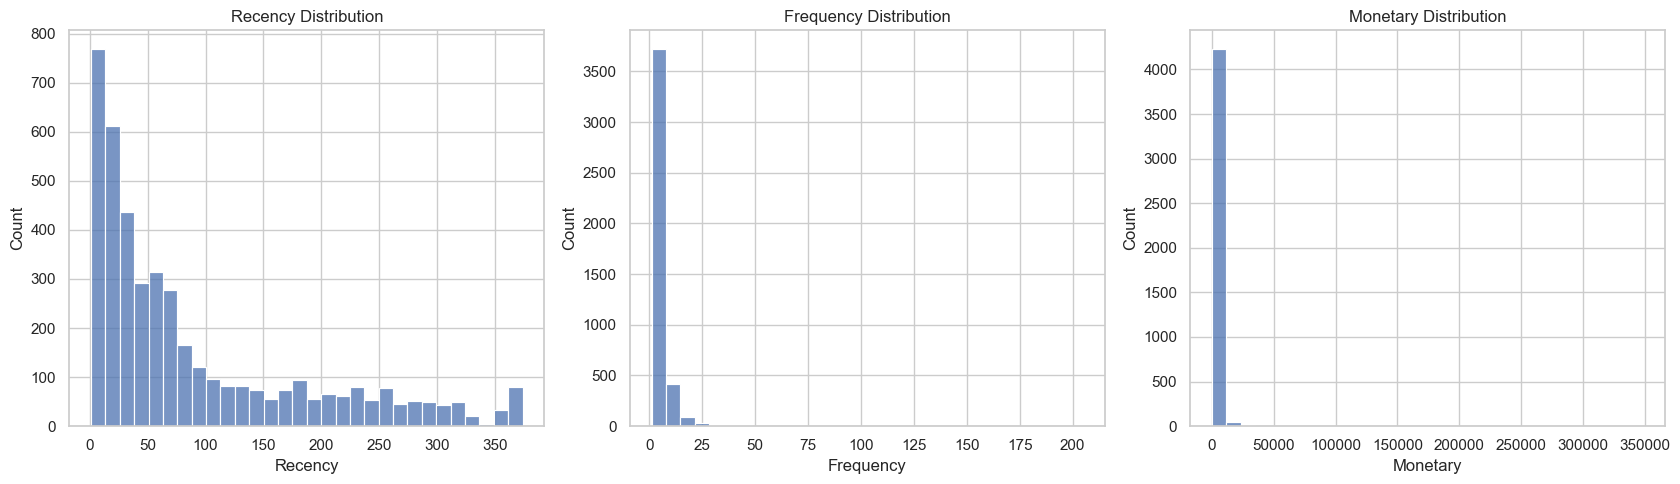

In [27]:
# ============================================================
# RFM DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

sns.histplot(
    rfm["Recency"],
    bins=30,
    ax=axes[0]
)

axes[0].set_title("Recency Distribution")

sns.histplot(
    rfm["Frequency"],
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Frequency Distribution")

sns.histplot(
    rfm["Monetary"],
    bins=30,
    ax=axes[2]
)

axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# RFM SCORING
# ============================================================

rfm_scored = rfm.copy()

# Rank first to make qcut robust when many values are tied
rfm_scored["R_score"] = pd.qcut(
    rfm_scored["Recency"]
    .rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm_scored["F_score"] = pd.qcut(
    rfm_scored["Frequency"]
    .rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_scored["M_score"] = pd.qcut(
    rfm_scored["Monetary"]
    .rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_scored["RFM_score"] = (
    rfm_scored["R_score"]
    + rfm_scored["F_score"]
    + rfm_scored["M_score"]
)

rfm_scored["RFM_code"] = (
    rfm_scored["R_score"].astype(str)
    + rfm_scored["F_score"].astype(str)
    + rfm_scored["M_score"].astype(str)
)

display(
    rfm_scored.head()
)

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_code
0,12346,165,11,372.86,2,5,2,9,252
1,12347,3,2,"1,323.32",5,2,4,11,524
2,12348,74,1,222.16,2,1,1,4,211
3,12349,43,3,"2,671.14",3,3,5,11,335
4,12351,11,1,300.93,5,1,2,8,512


In [57]:
# ============================================================
# BUSINESS-INTERPRETABLE CUSTOMER SEGMENTS
# ============================================================

def assign_segment(row):

    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4 and m >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "Recent / Low Frequency"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk - High Value"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif m >= 4:
        return "High Spenders"

    elif r >= 3 and f >= 3:
        return "Potential Loyalists"

    else:
        return "Needs Attention"


rfm_scored["Segment"] = rfm_scored.apply(
    assign_segment,
    axis=1
)

display(
    rfm_scored["Segment"]
    .value_counts()
    .to_frame("Customers")
)

,Customers
Segment,
Needs Attention,1278
Champions,911
At Risk - High Value,519
Loyal Customers,441
Potential Loyalists,388
Recent / Low Frequency,360
High Spenders,234
At Risk,181


In [30]:
# ============================================================
# SEGMENT PROFILE
# ============================================================

segment_profile = (
    rfm_scored
    .groupby("Segment")
    .agg(
        customers=("customer_id", "count"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean"),
        total_revenue=("Monetary", "sum")
    )
    .reset_index()
)

segment_profile["revenue_share"] = (
    segment_profile["total_revenue"]
    / segment_profile["total_revenue"].sum()
    * 100
)

display(
    segment_profile
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

,Segment,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_share
2,Champions,911,13.31,11.74,"6,199.68","5,647,909.97",64.19
1,At Risk - High Value,519,136.85,4.21,"1,936.32","1,004,950.23",11.42
4,Loyal Customers,441,40.63,5.58,"1,977.54","872,095.38",9.91
3,High Spenders,234,78.53,2.23,"1,932.62","452,232.06",5.14
5,Needs Attention,1278,174.15,1.12,301.56,"385,394.57",4.38
7,Potential Loyalists,388,30.29,2.54,522.55,"202,750.64",2.30
6,New / Promising,360,19.51,1.30,491.63,"176,986.78",2.01
0,At Risk,181,178.74,2.55,308.92,"55,914.11",0.64


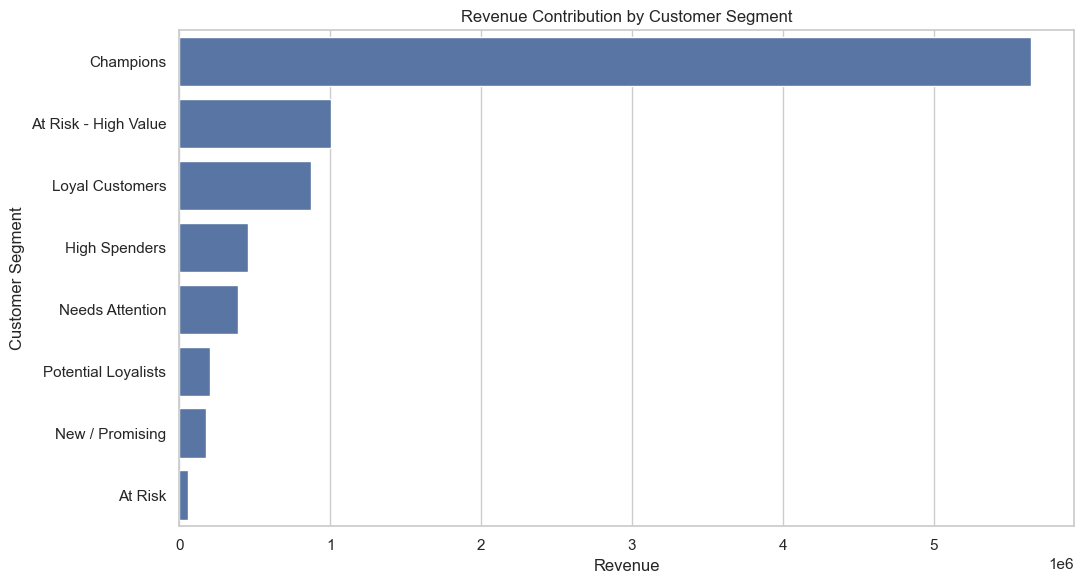

In [31]:
# ============================================================
# SEGMENT REVENUE
# ============================================================

plot_data = (
    segment_profile
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_data,
    x="total_revenue",
    y="Segment"
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Revenue")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# COHORT ANALYSIS PREPARATION
# ============================================================

cohort_data = transactions[
    [
        "customer_id",
        "invoicedate",
        "revenue"
    ]
].copy()

cohort_data["invoice_month"] = (
    cohort_data["invoicedate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

first_purchase_month = (
    cohort_data
    .groupby("customer_id")["invoice_month"]
    .transform("min")
)

cohort_data["cohort_month"] = (
    first_purchase_month
)

cohort_data["cohort_period"] = (
    (
        cohort_data["invoice_month"].dt.year
        - cohort_data["cohort_month"].dt.year
    ) * 12
    +
    (
        cohort_data["invoice_month"].dt.month
        - cohort_data["cohort_month"].dt.month
    )
    + 1
)

display(
    cohort_data.head()
)

,customer_id,invoicedate,revenue,invoice_month,cohort_month,cohort_period
0,13085,2009-12-01 07:45:00,83.40,2009-12-01,2009-12-01,1
1,13085,2009-12-01 07:45:00,81.00,2009-12-01,2009-12-01,1
2,13085,2009-12-01 07:45:00,81.00,2009-12-01,2009-12-01,1
3,13085,2009-12-01 07:45:00,100.80,2009-12-01,2009-12-01,1
4,13085,2009-12-01 07:45:00,30.00,2009-12-01,2009-12-01,1


In [33]:
# ============================================================
# COHORT RETENTION MATRIX
# ============================================================

cohort_counts = (
    cohort_data
    .groupby(
        [
            "cohort_month",
            "cohort_period"
        ]
    )["customer_id"]
    .nunique()
    .reset_index()
)

cohort_matrix = (
    cohort_counts
    .pivot(
        index="cohort_month",
        columns="cohort_period",
        values="customer_id"
    )
)

cohort_sizes = (
    cohort_matrix.iloc[:, 0]
)

retention_matrix = (
    cohort_matrix
    .divide(
        cohort_sizes,
        axis=0
    )
)

retention_matrix = (
    retention_matrix
    * 100
)

display(
    retention_matrix.round(1)
)

cohort_period,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_month,,,,,,,,,,,,,
2009-12-01,100.00,35.30,33.40,42.50,38.00,35.90,37.70,34.20,33.60,36.20,42.20,49.50,24.80
2010-01-01,100.00,20.60,31.10,30.50,26.40,30.00,25.80,23.00,27.90,31.90,30.30,9.90,NaN
2010-02-01,100.00,23.80,22.50,29.10,24.60,20.10,19.30,28.60,25.40,27.50,7.20,NaN,NaN
2010-03-01,100.00,19.00,23.00,24.20,23.30,20.30,24.60,30.20,27.50,7.90,NaN,NaN,NaN
2010-04-01,100.00,19.40,19.40,16.30,18.40,22.40,27.60,26.20,6.80,NaN,NaN,NaN,NaN
2010-05-01,100.00,15.70,16.90,17.30,17.70,25.60,21.30,7.90,NaN,NaN,NaN,NaN,NaN
2010-06-01,100.00,17.40,18.90,20.40,23.00,28.50,6.70,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,100.00,15.60,18.30,29.60,29.00,10.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,100.00,20.40,29.60,32.10,11.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


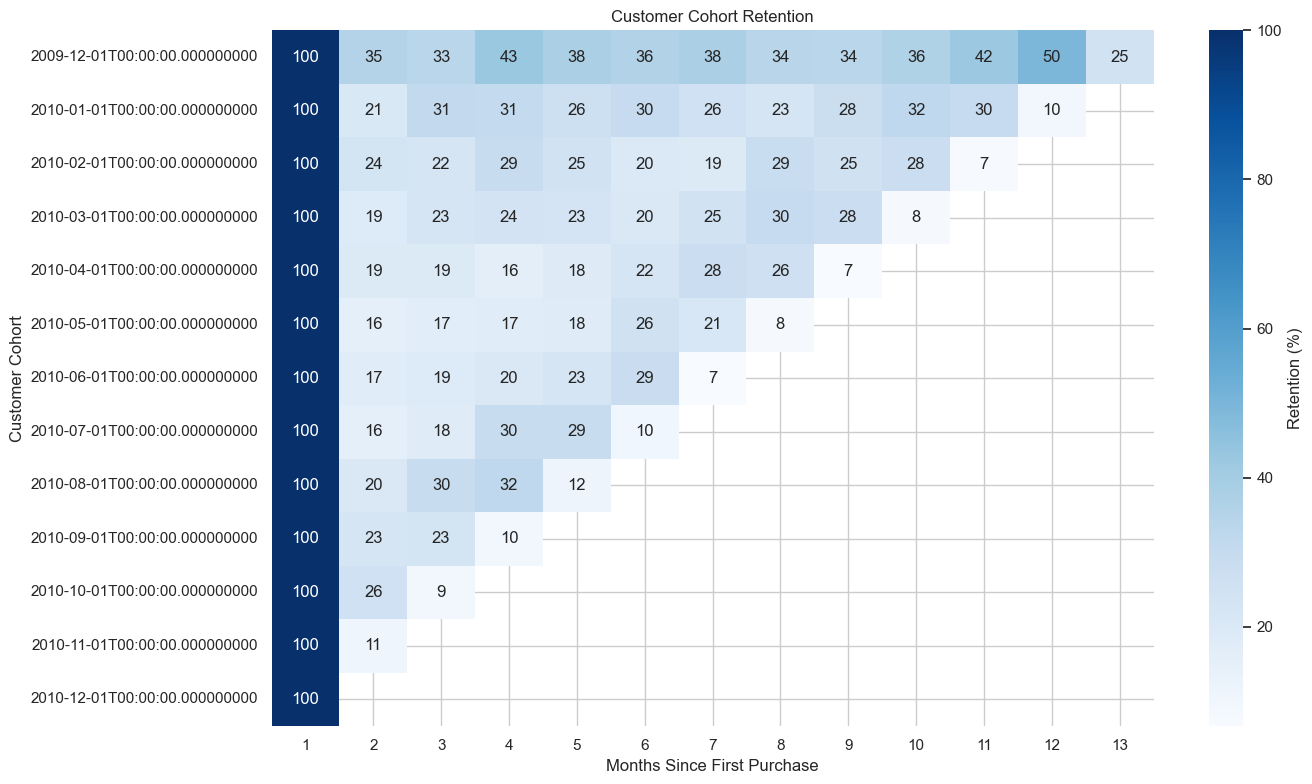

In [34]:
# ============================================================
# COHORT RETENTION HEATMAP
# ============================================================

plt.figure(
    figsize=(14, 8)
)

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar_kws={
        "label": "Retention (%)"
    }
)

plt.title(
    "Customer Cohort Retention"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.ylabel(
    "Customer Cohort"
)

plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# K-MEANS CUSTOMER SEGMENTATION
# ============================================================

cluster_features = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].copy()

# Log transformation reduces the effect of highly skewed values
cluster_features["Recency"] = np.log1p(
    cluster_features["Recency"]
)

cluster_features["Frequency"] = np.log1p(
    cluster_features["Frequency"]
)

cluster_features["Monetary"] = np.log1p(
    cluster_features["Monetary"]
)

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    cluster_features
)

print(
    "Clustering matrix shape:",
    X_cluster.shape
)

Clustering matrix shape: (4312, 3)


In [36]:
# ============================================================
# K-MEANS MODEL SELECTION
# ============================================================

cluster_scores = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = model.fit_predict(
        X_cluster
    )

    score = silhouette_score(
        X_cluster,
        labels
    )

    cluster_scores.append({
        "K": k,
        "Silhouette_Score": score
    })

cluster_scores = pd.DataFrame(
    cluster_scores
)

display(cluster_scores)

,K,Silhouette_Score
0,2,0.42
1,3,0.33
2,4,0.33
3,5,0.32
4,6,0.31
5,7,0.31
6,8,0.28


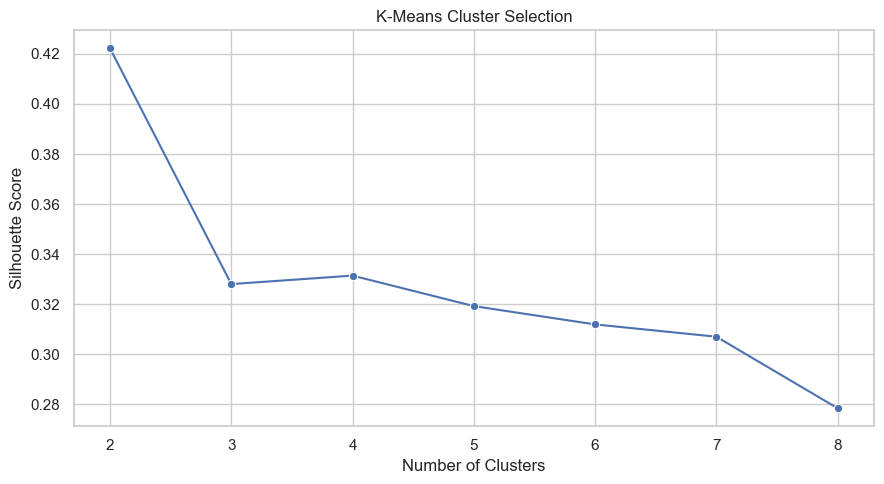

In [37]:
# ============================================================
# SILHOUETTE SCORE
# ============================================================

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=cluster_scores,
    x="K",
    y="Silhouette_Score",
    marker="o"
)

plt.title(
    "K-Means Cluster Selection"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Silhouette Score"
)

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# SELECT OPTIMAL NUMBER OF CLUSTERS
# ============================================================

best_k = int(
    cluster_scores.loc[
        cluster_scores["Silhouette_Score"].idxmax(),
        "K"
    ]
)

best_score = cluster_scores["Silhouette_Score"].max()

print(f"Optimal number of clusters: {best_k}")
print(f"Best silhouette score: {best_score:.2f}")

Optimal number of clusters: 2
Best silhouette score: 0.42


In [39]:
# ============================================================
# CLUSTER PROFILE
# ============================================================

cluster_profile = (
    rfm_scored
    .groupby("Cluster")
    .agg(
        customers=("customer_id", "count"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean"),
        total_revenue=("Monetary", "sum")
    )
    .reset_index()
)

display(
    cluster_profile
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

,Cluster,customers,avg_recency,avg_frequency,avg_monetary,total_revenue
1,1,1642,29.68,8.88,"4,516.50","7,416,092.30"
0,0,2670,128.99,1.73,517.66,"1,382,141.45"


In [40]:
# ============================================================
# CLV LIBRARY CHECK
# ============================================================

try:

    from lifetimes import BetaGeoFitter
    from lifetimes import GammaGammaFitter

    print(
        "lifetimes is ready."
    )

except ImportError:

    raise ImportError(
        "Please run the installation cell first."
    )

lifetimes is ready.


In [41]:
# ============================================================
# CLV INPUT DATA
# ============================================================

clv_base = (
    transactions
    .groupby("customer_id")
    .agg(
        first_purchase=("invoicedate", "min"),
        last_purchase=("invoicedate", "max"),
        transaction_count=(
            "invoice_str",
            "nunique"
        ),
        monetary_value=(
            "revenue",
            "sum"
        )
    )
    .reset_index()
)

clv_base["frequency"] = (
    clv_base["transaction_count"] - 1
)

clv_base["recency"] = (
    clv_base["last_purchase"]
    - clv_base["first_purchase"]
).dt.days

clv_base["T"] = (
    analysis_date
    - clv_base["first_purchase"]
).dt.days

clv_base["monetary_value"] = (
    clv_base["monetary_value"]
    / clv_base["transaction_count"]
)

clv_base = clv_base[
    clv_base["T"] > 0
].copy()

display(
    clv_base.head()
)

,customer_id,first_purchase,last_purchase,transaction_count,monetary_value,frequency,recency,T
0,12346,2009-12-14 08:34:00,2010-06-28 13:53:00,11,33.90,10,196,361
1,12347,2010-10-31 14:20:00,2010-12-07 14:57:00,2,661.66,1,37,40
2,12348,2010-09-27 14:59:00,2010-09-27 14:59:00,1,222.16,0,0,74
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,3,890.38,2,181,225
4,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,300.93,0,0,11


In [42]:
# ============================================================
# BG/NBD CUSTOMER PURCHASE MODEL
# ============================================================

bgf = BetaGeoFitter(
    penalizer_coef=0.001
)

bgf.fit(
    frequency=clv_base["frequency"],
    recency=clv_base["recency"],
    T=clv_base["T"]
)

clv_base["expected_purchases_90d"] = (
    bgf.conditional_expected_number_of_purchases_up_to_time(
        90,
        clv_base["frequency"],
        clv_base["recency"],
        clv_base["T"]
    )
)

display(
    clv_base[
        [
            "customer_id",
            "frequency",
            "recency",
            "T",
            "expected_purchases_90d"
        ]
    ].head(10)
)

,customer_id,frequency,recency,T,expected_purchases_90d
0,12346,10,196,361,1.40
1,12347,1,37,40,1.66
2,12348,0,0,74,NaN
3,12349,2,181,225,0.88
4,12351,0,0,11,NaN
5,12352,1,16,28,1.90
6,12353,0,0,44,NaN
7,12355,0,0,203,NaN
8,12356,2,44,60,2.16
9,12357,1,0,24,1.96


In [43]:
# ============================================================
# GAMMA-GAMMA CUSTOMER VALUE MODEL
# ============================================================

gg_data = clv_base[
    (clv_base["frequency"] > 0)
    &
    (clv_base["monetary_value"] > 0)
].copy()

ggf = GammaGammaFitter(
    penalizer_coef=0.001
)

ggf.fit(
    gg_data["frequency"],
    gg_data["monetary_value"]
)

gg_data["expected_average_profit"] = (
    ggf.conditional_expected_average_profit(
        gg_data["frequency"],
        gg_data["monetary_value"]
    )
)

display(
    gg_data[
        [
            "customer_id",
            "frequency",
            "monetary_value",
            "expected_average_profit"
        ]
    ].head(10)
)

,customer_id,frequency,monetary_value,expected_average_profit
0,12346,10,33.90,35.14
1,12347,1,661.66,677.81
3,12349,2,890.38,899.10
5,12352,1,171.90,185.17
8,12356,2,"1,186.77","1,196.36"
9,12357,1,"6,039.99","6,087.76"
10,12358,2,906.34,915.10
11,12359,5,427.23,430.17
12,12360,4,318.17,321.68
13,12361,2,107.12,113.54


In [44]:
# ============================================================
# CUSTOMER LIFETIME VALUE
# ============================================================

gg_data["predicted_clv_12m"] = (
    ggf.customer_lifetime_value(
        bgf,
        gg_data["frequency"],
        gg_data["recency"],
        gg_data["T"],
        gg_data["monetary_value"],
        time=12,
        freq="D",
        discount_rate=0.01
    )
)

gg_data["predicted_clv_12m"] = (
    gg_data["predicted_clv_12m"]
    .clip(lower=0)
)

display(
    gg_data[
        [
            "customer_id",
            "predicted_clv_12m"
        ]
    ]
    .sort_values(
        "predicted_clv_12m",
        ascending=False
    )
    .head(20)
)

,customer_id,predicted_clv_12m
4183,18102,"274,014.87"
1637,14646,"194,866.62"
1269,14156,"154,077.62"
3704,17450,"132,860.26"
1840,14911,"119,586.71"
939,13694,"103,656.04"
3744,17511,"66,120.37"
3177,16754,"65,995.50"
1951,15061,"65,347.23"
3128,16684,"63,513.55"


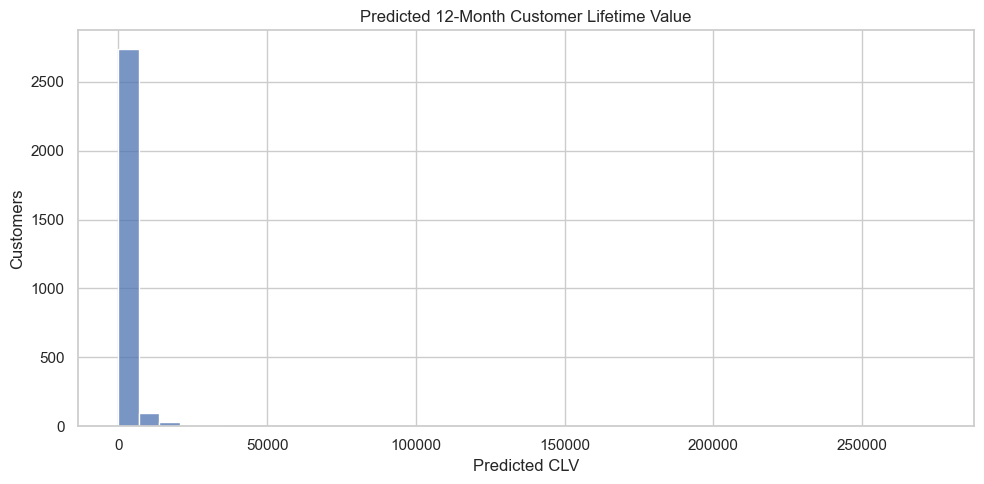

In [45]:
# ============================================================
# CLV DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    gg_data["predicted_clv_12m"],
    bins=40
)

plt.title(
    "Predicted 12-Month Customer Lifetime Value"
)

plt.xlabel(
    "Predicted CLV"
)

plt.ylabel(
    "Customers"
)

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# CLV SEGMENTATION
# ============================================================

gg_data["CLV_segment"] = pd.qcut(
    gg_data["predicted_clv_12m"]
    .rank(method="first"),
    q=4,
    labels=[
        "Low CLV",
        "Mid-Low CLV",
        "Mid-High CLV",
        "High CLV"
    ]
)

clv_segment_summary = (
    gg_data
    .groupby("CLV_segment", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_clv=("predicted_clv_12m", "mean"),
        total_expected_value=(
            "predicted_clv_12m",
            "sum"
        )
    )
    .reset_index()
)

display(
    clv_segment_summary
)

,CLV_segment,customers,avg_clv,total_expected_value
0,Low CLV,724,404.55,"292,893.26"
1,Mid-Low CLV,723,985.00,"712,157.67"
2,Mid-High CLV,723,"1,847.03","1,335,405.41"
3,High CLV,723,"7,705.05","5,570,748.00"


In [47]:
# ============================================================
# CUSTOMER 360 ANALYTICAL TABLE
# ============================================================

customer_360 = (
    rfm_scored
    .merge(
        gg_data[
            [
                "customer_id",
                "expected_purchases_90d",
                "expected_average_profit",
                "predicted_clv_12m",
                "CLV_segment"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

customer_360 = (
    customer_360
    .merge(
        customer_summary[
            [
                "customer_id",
                "first_purchase",
                "last_purchase",
                "orders",
                "items",
                "revenue",
                "average_order_value"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

display(
    customer_360.head()
)

print(
    "Customer 360 shape:",
    customer_360.shape
)

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_code,Segment,Cluster,expected_purchases_90d,expected_average_profit,predicted_clv_12m,CLV_segment,first_purchase,last_purchase,orders,items,revenue,average_order_value
0,12346,165,11,372.86,2,5,2,9,252,At Risk,0,1.40,35.14,183.64,Low CLV,2009-12-14 08:34:00,2010-06-28 13:53:00,11,70,372.86,33.90
1,12347,3,2,"1,323.32",5,2,4,11,524,New / Promising,1,1.66,677.81,"4,143.15",High CLV,2010-10-31 14:20:00,2010-12-07 14:57:00,2,828,"1,323.32",661.66
2,12348,74,1,222.16,2,1,1,4,211,Needs Attention,0,NaN,NaN,NaN,NaN,2010-09-27 14:59:00,2010-09-27 14:59:00,1,373,222.16,222.16
3,12349,43,3,"2,671.14",3,3,5,11,335,High Spenders,1,0.88,899.10,"2,922.77",High CLV,2010-04-29 13:20:00,2010-10-28 08:23:00,3,993,"2,671.14",890.38
4,12351,11,1,300.93,5,1,2,8,512,New / Promising,0,NaN,NaN,NaN,NaN,2010-11-29 15:23:00,2010-11-29 15:23:00,1,261,300.93,300.93


Customer 360 shape: (4312, 21)


In [59]:
# ============================================================
# CUSTOMER PRIORITY FRAMEWORK
# ============================================================

customer_360["priority_score"] = (
    customer_360["R_score"]
    + customer_360["F_score"]
    + customer_360["M_score"]
)

# Give additional priority to customers with above-median
# predicted future value
clv_median = customer_360[
    "predicted_clv_12m"
].median()

customer_360["priority_score"] += np.where(
    customer_360["predicted_clv_12m"] >= clv_median,
    2,
    0
)

def priority_label(score):

    if score >= 14:
        return "VIP / Immediate Attention"

    elif score >= 11:
        return "High Priority"

    elif score >= 8:
        return "Medium Priority"

    else:
        return "Low Priority"


customer_360["Priority"] = (
    customer_360["priority_score"]
    .apply(priority_label)
)

display(
    customer_360[
        [
            "customer_id",
            "Segment",
            "CLV_segment",
            "predicted_clv_12m",
            "priority_score",
            "Priority"
        ]
    ].head(20)
)

,customer_id,Segment,CLV_segment,predicted_clv_12m,priority_score,Priority
0,12346,At Risk,Low CLV,183.64,9,Medium Priority
1,12347,New / Promising,High CLV,"4,143.15",13,High Priority
2,12348,Needs Attention,NaN,NaN,4,Low Priority
3,12349,High Spenders,High CLV,"2,922.77",13,High Priority
4,12351,New / Promising,NaN,NaN,8,Medium Priority
5,12352,New / Promising,Mid-Low CLV,"1,289.47",9,Medium Priority
6,12353,Needs Attention,NaN,NaN,6,Low Priority
7,12355,Needs Attention,NaN,NaN,4,Low Priority
8,12356,High Spenders,High CLV,"9,552.47",14,VIP / Immediate Attention
9,12357,New / Promising,High CLV,"43,786.70",13,High Priority


In [49]:
# ============================================================
# HIGH-VALUE AT-RISK CUSTOMERS
# ============================================================

high_value_risk = customer_360[
    (
        customer_360["Segment"]
        .isin(
            [
                "At Risk - High Value",
                "At Risk"
            ]
        )
    )
    &
    (
        customer_360["predicted_clv_12m"]
        >= customer_360["predicted_clv_12m"].quantile(
            0.75
        )
    )
].copy()

high_value_risk = (
    high_value_risk
    .sort_values(
        "predicted_clv_12m",
        ascending=False
    )
)

display(
    high_value_risk[
        [
            "customer_id",
            "Recency",
            "Frequency",
            "Monetary",
            "Segment",
            "predicted_clv_12m",
            "Priority"
        ]
    ].head(25)
)

,customer_id,Recency,Frequency,Monetary,Segment,predicted_clv_12m,Priority
4061,17940,81,6,"26,286.75",At Risk - High Value,"19,609.91",VIP / Immediate Attention
1205,14063,74,9,"22,710.20",At Risk - High Value,"17,376.90",VIP / Immediate Attention
4280,18251,81,8,"21,964.14",At Risk - High Value,"17,267.87",VIP / Immediate Attention
1091,13902,268,5,"34,095.26",At Risk - High Value,"12,848.58",High Priority
3451,17133,110,5,"9,730.09",At Risk - High Value,"9,331.00",High Priority
2444,15760,266,2,"13,916.34",At Risk - High Value,"7,337.08",High Priority
2760,16180,114,5,"5,995.69",At Risk - High Value,"7,061.11",High Priority
1179,14028,186,3,"10,396.50",At Risk - High Value,"6,749.30",High Priority
968,13734,144,4,"6,695.69",At Risk - High Value,"6,472.08",High Priority
239,12731,78,5,"6,879.80",At Risk - High Value,"6,406.70",High Priority


In [60]:
clv_75th_percentile = (
    customer_360["predicted_clv_12m"]
    .quantile(0.75)
)

print(
    f"High-value CLV threshold: "
    f"{clv_75th_percentile:,.2f}"
)

High-value CLV threshold: 2,578.47


In [62]:
# ============================================================
# EXECUTIVE CUSTOMER SEGMENT SUMMARY
# ============================================================

executive_summary = (
    customer_360
    .groupby("Segment")
    .agg(
        customers=("customer_id", "count"),
        revenue=("Monetary", "sum"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_clv=("predicted_clv_12m", "mean"),
        total_predicted_clv=(
            "predicted_clv_12m",
            "sum"
        )
    )
    .reset_index()
)

executive_summary["revenue_share"] = (
    executive_summary["revenue"]
    / executive_summary["revenue"].sum()
    * 100


    
)

display(
    executive_summary
    .sort_values(
        "total_predicted_clv",
        ascending=False
    )
)

,Segment,customers,revenue,avg_recency,avg_frequency,avg_clv,total_predicted_clv,revenue_share
2,Champions,911,"5,647,909.97",13.31,11.74,"5,613.15","5,113,578.65",64.19
4,Loyal Customers,441,"872,095.38",40.63,5.58,"1,915.93","844,926.42",9.91
1,At Risk - High Value,519,"1,004,950.23",136.85,4.21,"1,478.39","767,284.41",11.42
3,High Spenders,234,"452,232.06",78.53,2.23,"2,626.72","488,570.13",5.14
7,Potential Loyalists,388,"202,750.64",30.29,2.54,864.19,"335,307.18",2.30
6,New / Promising,360,"176,986.78",19.51,1.30,"2,020.68","218,233.30",2.01
5,Needs Attention,1278,"385,394.57",174.15,1.12,587.08,"93,346.09",4.38
0,At Risk,181,"55,914.11",178.74,2.55,276.01,"49,958.17",0.64


In [63]:
# ============================================================
# EXPORT CUSTOMER INTELLIGENCE OUTPUT
# ============================================================

output_path = (
    "customer_intelligence_output.csv"
)

customer_360.to_csv(
    output_path,
    index=False
)

print(
    f"Customer intelligence table saved to: "
    f"{output_path}"
)

Customer intelligence table saved to: customer_intelligence_output.csv


In [52]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 65)
print("E-COMMERCE CUSTOMER INTELLIGENCE PROJECT")
print("=" * 65)

print(
    f"Customers analyzed       : "
    f"{transactions['customer_id'].nunique():,}"
)

print(
    f"Orders analyzed           : "
    f"{transactions['invoice_str'].nunique():,}"
)

print(
    f"Products analyzed         : "
    f"{transactions['stockcode'].nunique():,}"
)

print(
    f"Total revenue             : "
    f"{transactions['revenue'].sum():,.2f}"
)

print(
    f"Average order value       : "
    f"{average_order_value:,.2f}"
)

print(
    f"RFM segments              : "
    f"{customer_360['Segment'].nunique()}"
)

print(
    f"K-Means clusters          : "
    f"{best_k}"
)

print(
    f"CLV customers modeled     : "
    f"{gg_data['customer_id'].nunique():,}"
)

print(
    f"Highest predicted 12M CLV : "
    f"{gg_data['predicted_clv_12m'].max():,.2f}"
)

print("=" * 65)

E-COMMERCE CUSTOMER INTELLIGENCE PROJECT
Customers analyzed       : 4,312
Orders analyzed           : 19,213
Products analyzed         : 4,017
Total revenue             : 8,798,233.74
Average order value       : 457.93
RFM segments              : 8
K-Means clusters          : 2
CLV customers modeled     : 2,893
Highest predicted 12M CLV : 274,014.87
